In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import numpy as np
import cv2

In [3]:
impath = r"C:\Users\omarh\OneDrive - Georgia Institute of Technology\openEDS2019\openEDS\openEDS\S_0\0.png"
impath2 = r"C:\Users\omarh\OneDrive - Georgia Institute of Technology\openEDS2019\openEDS\openEDS\S_0\1.png"
img = cv2.imread(impath, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(impath2, cv2.IMREAD_GRAYSCALE)


In [29]:
diff = abs(img2 - img)
diff_normalized = diff/255.0

threshold_value = 0.05
binary_img = np.where(img > threshold_value, 1, 0).astype(np.float32)

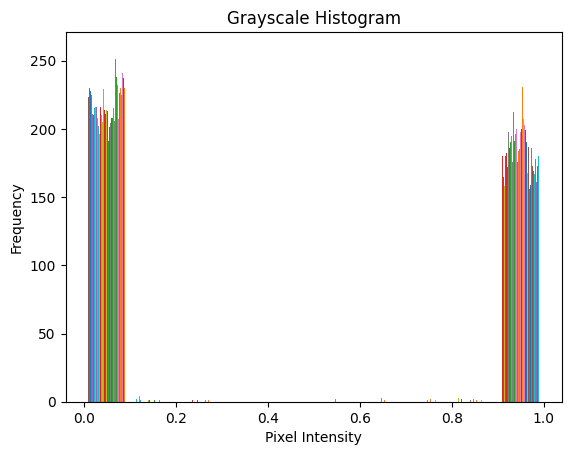

In [30]:
plt.hist(diff_normalized)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

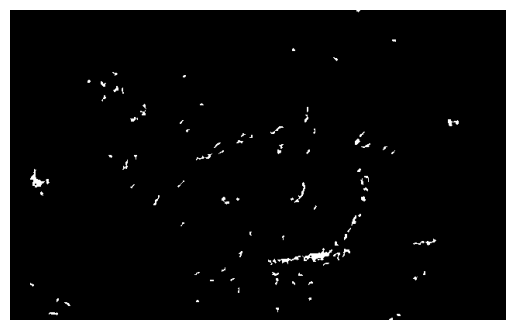

In [45]:
diff_blurred = cv2.GaussianBlur(diff_normalized, (5, 5), 0)

threshold_value = 0.8
binary_img = np.where(diff_blurred > threshold_value, 1.0, 0.0)

diff_vis = (binary_img*255).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(diff_vis, connectivity=8)

# Step 2: Filter out small blobs
min_area = 10  # You can tune this: 50, 100, 200 depending on how clean you want
for i in range(1, num_labels):  # skip label 0 (background)
    if stats[i, cv2.CC_STAT_AREA] < min_area:
        diff_vis[labels == i] = 0

plt.figure()
plt.set_cmap('gray')
plt.imshow(diff_vis)
plt.axis('off')
plt.show()

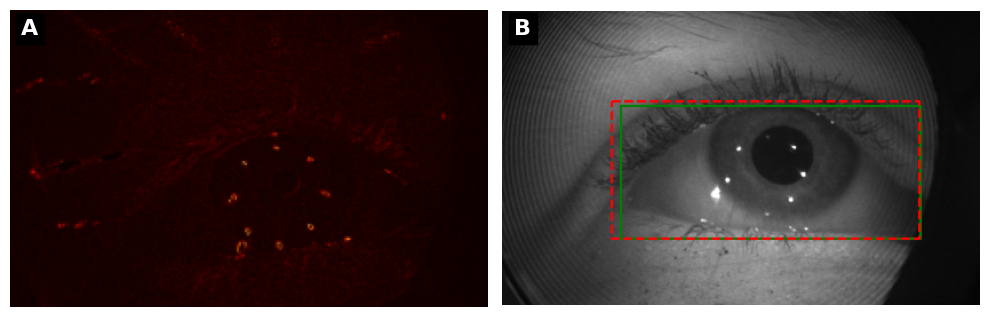

In [50]:
# Load your two images
imgA = cv2.imread('figs/diff.png')
imgB = cv2.imread('figs/roi_pred.png')

# Convert from BGR to RGB for correct color in matplotlib
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Plot image A
axes[0].imshow(imgA)
axes[0].axis('off')
axes[0].text(5, 12, 'A', fontsize=16, fontweight='bold', color='white', backgroundcolor='black')

# Plot image B
axes[1].imshow(imgB)
axes[1].axis('off')
axes[1].text(10, 20, 'B', fontsize=16, fontweight='bold', color='white', backgroundcolor='black')

# Adjust spacing
plt.tight_layout()
plt.show()